# Extracting features from SONATA Network simulations

This notebook shows how to extract features of a group of cells from a SONATA network, specifically focusing on a small portion of non-barrel primary somatosensory cortex circuit from juvenile rats, with the help of [BlueCellulLab](https://github.com/BlueBrain/BlueCelluLab/). For those interested in conducting a more in-depth analysis, the entire circuit dataset is accessible on [Zenodo](https://zenodo.org/records/8026353). For more details about the simulation and in-depth insights on the circuit, please refer to the Bluecellulab [SONATA Network example](https://github.com/BlueBrain/BlueCelluLab/blob/main/examples/2-sonata-network/sonata-network.ipynb) and the related [paper](https://www.biorxiv.org/content/10.1101/2023.05.17.541168v2.abstract), respectively.


The small microcircuit in the `./circuit.gz` file has been extracted from the bigger circuit mentioned above. 

It is also avaialble on the [Open Brain Institute](https://www.openbraininstitute.org/) Virtual Lab at this link (login needed) : 
https://www.openbraininstitute.org/app/entity/92a1a454-3d22-466d-943f-adb065176875

In [1]:
#compresss the circuit.gz file
!tar -xf circuit.gz

**Note**: The compiled mechanisms need to be provided before importing bluecellulab.

In [ ]:
!nrnivmodl nbS1-O1-sSub-post-dim5-nCN-HEX0-L1-01/mod

In [3]:
import json
from pathlib import Path

from matplotlib import pyplot as plt

from bluecellulab import CircuitSimulation
import efel

In this example, a small sub-circuit has been extracted from the [sscx circuit](https://zenodo.org/records/8026353). This sub-circuit specifically consists of a random selection of cells exhibiting delayed stuttering (dSTUT) etype. 

The simulation_config specifies the types of input stimuli to be applied to the cells. In this case, we have selected a 'relative_linear' stimulus of 70 ms and set the stimulus current at a level equivalent to 100 percent of the cell's threshold current.

In [4]:
simulation_config = Path("./") / "simulation_config.json"
with open(simulation_config) as f:
    simulation_config_dict = json.load(f)
print(json.dumps(simulation_config_dict, indent=4))

{
    "version": 2.4,
    "target_simulator": "NEURON",
    "run": {
        "dt": 0.025,
        "random_seed": 1,
        "tstop": 1000.0
    },
    "conditions": {
        "extracellular_calcium": 1.1,
        "v_init": -80.0,
        "spike_location": "soma"
    },
    "output": {
        "output_dir": "output",
        "spikes_file": "spikes.h5"
    },
    "network": "nbS1-O1-sSub-post-dim5-nCN-HEX0-L1-01/circuit_config.json",
    "node_set": "Default: All Biophysical Neurons",
    "inputs": {
        "Stimulus 1_0": {
            "delay": 200.0,
            "duration": 600.0,
            "node_set": "Default: All Biophysical Neurons",
            "module": "relative_linear",
            "input_type": "current_clamp",
            "percent_start": 150.0,
            "represents_physical_electrode": false
        },
        "Stimulus 2_0": {
            "delay": 0.0,
            "duration": 1000.0,
            "node_set": "Default: All Biophysical Neurons",
            "module": "hy

We use BlueCellulab for simulating smaller scale circuits, in contrast to the larger-scale simulations conducted with Neurodamus.

In [5]:
simulation_config = Path("./") / "simulation_config.json"
with open(simulation_config) as f:
    simulation_config_dict = json.load(f)
sim = CircuitSimulation(simulation_config)

In [6]:
from bluepysnap import Simulation as snap_sim
snap_access = snap_sim(simulation_config)
import pandas as pd
from bluepysnap import Simulation as snap_sim
# Get all biophysical neurons from the S1nonbarrel_neurons population
bio_pop = snap_access.circuit.nodes['S1nonbarrel_neurons']
all_cells = [('S1nonbarrel_neurons', nid) for nid in bio_pop.get().index.tolist()]
all_cells


[('S1nonbarrel_neurons', 0),
 ('S1nonbarrel_neurons', 1),
 ('S1nonbarrel_neurons', 2),
 ('S1nonbarrel_neurons', 3),
 ('S1nonbarrel_neurons', 4),
 ('S1nonbarrel_neurons', 5)]

In [7]:
# instantiate all the cells
sim.instantiate_gids(all_cells, add_stimuli=True, add_relativelinear_stimuli=True)

t_stop = 1000.0
sim.run(t_stop)

The plot displays the voltage traces simulated for each cell in our circuit.

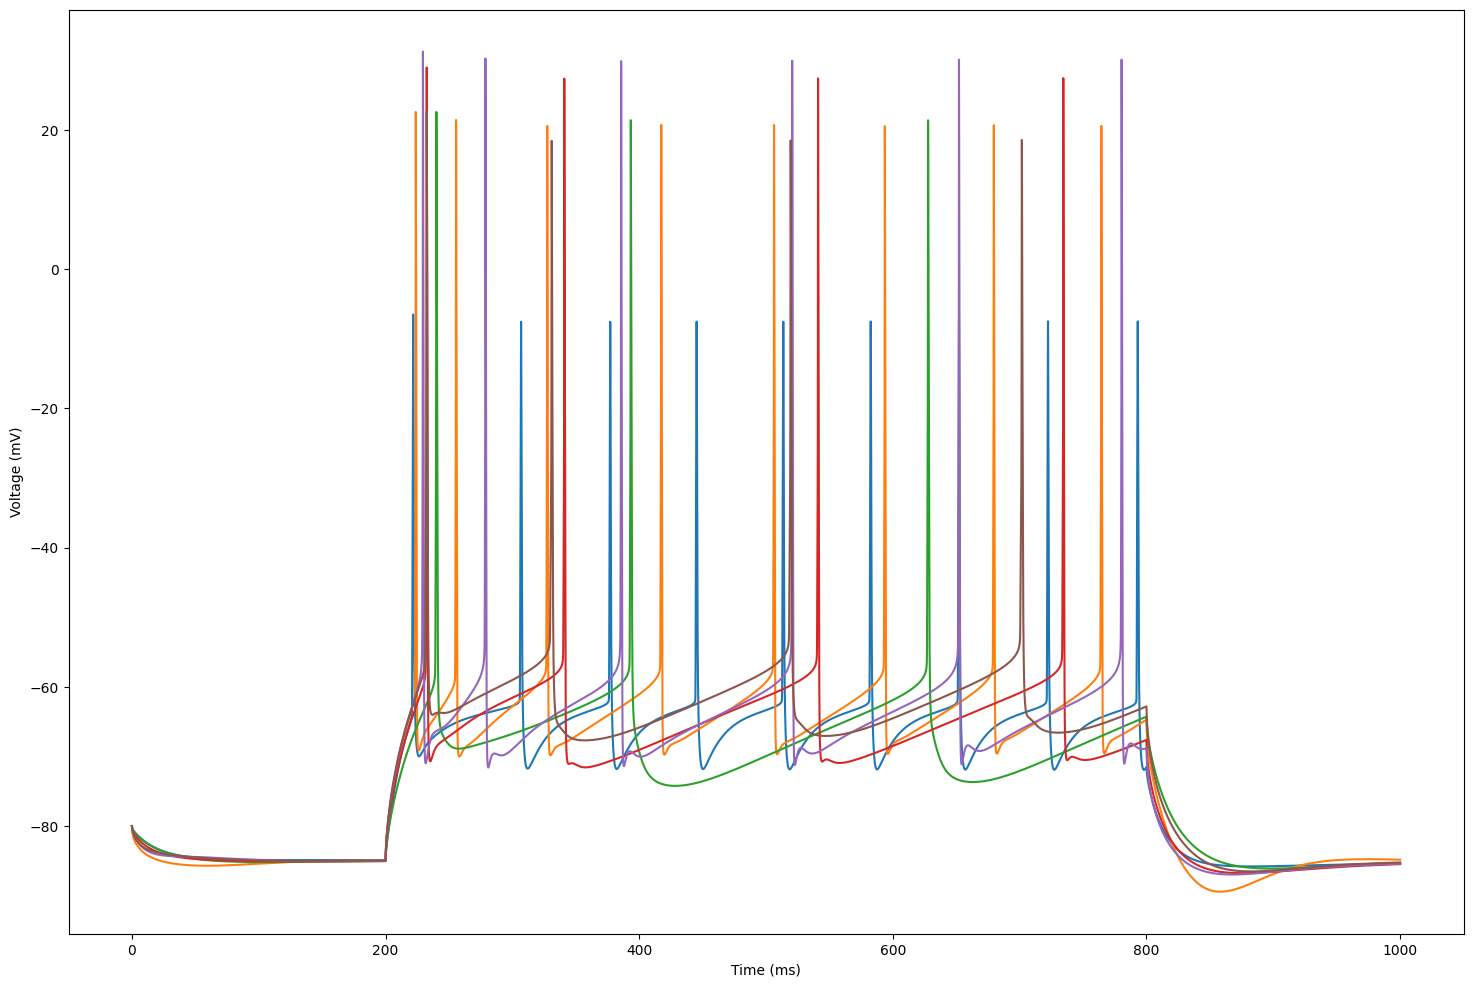

In [8]:
plt.figure(figsize=(18, 12))
for cell_id in sim.cells:
    time = sim.get_time_trace()
    voltage = sim.get_voltage_trace(cell_id)
    plt.plot(time, voltage, label=str(cell_id))
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")

Let's focus on 3 cells for better visualization

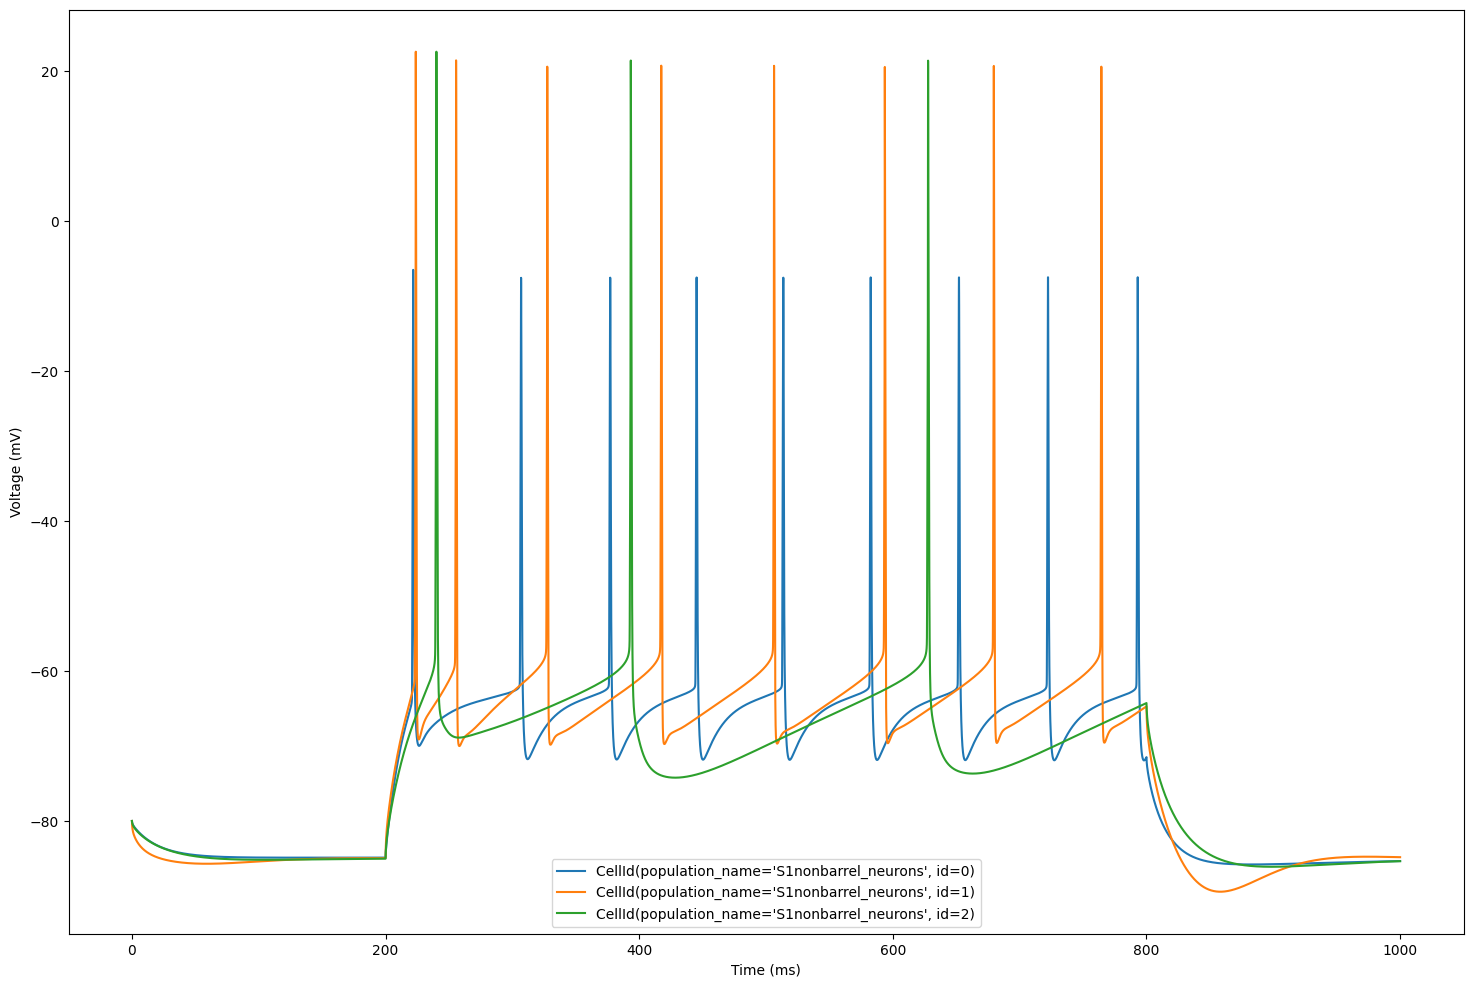

In [9]:
sim.cells = dict(list(sim.cells.items())[:3])
plt.figure(figsize=(18, 12))
for cell_id in sim.cells:
    time = sim.get_time_trace()
    voltage = sim.get_voltage_trace(cell_id)
    plt.plot(time, voltage, label=str(cell_id))
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()

We are now ready to extract features. First, we will build the data structure for eFEL

In [10]:
traces = []
for cell_id in sim.cells:
    voltage = sim.get_voltage_trace(cell_id)
    trace = {}
    trace['T'] = time
    trace['V'] = voltage
    trace['stim_start'] = [20]
    trace['stim_end'] = [90]
    traces.append(trace)

Next, we choose the specific features of interest

In [11]:
features = ['peak_time', 'AHP_time_from_peak', 'AP_height', 'AHP_depth_abs', 'all_ISI_values']

Finally, we perform the feature extraction

In [12]:
traces_results = efel.get_feature_values(traces, features)

The plot below shows action potential (AP) height and depth of those 3 cells

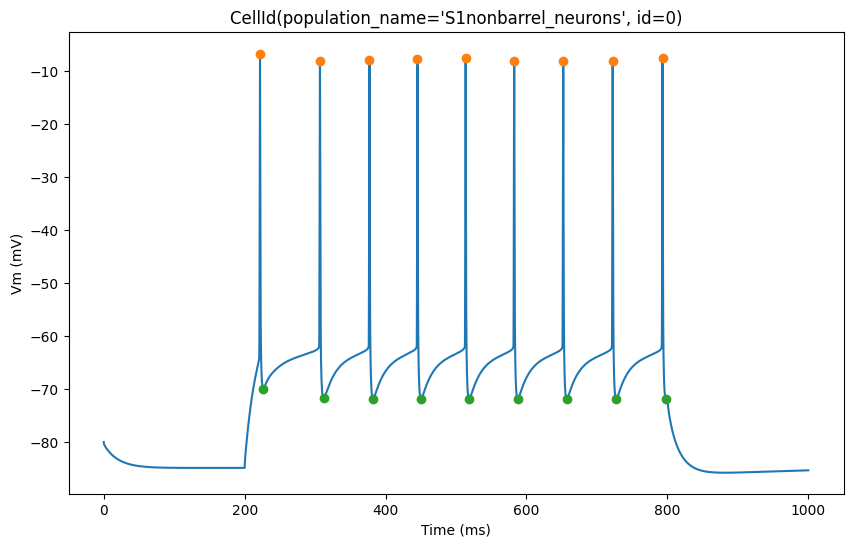

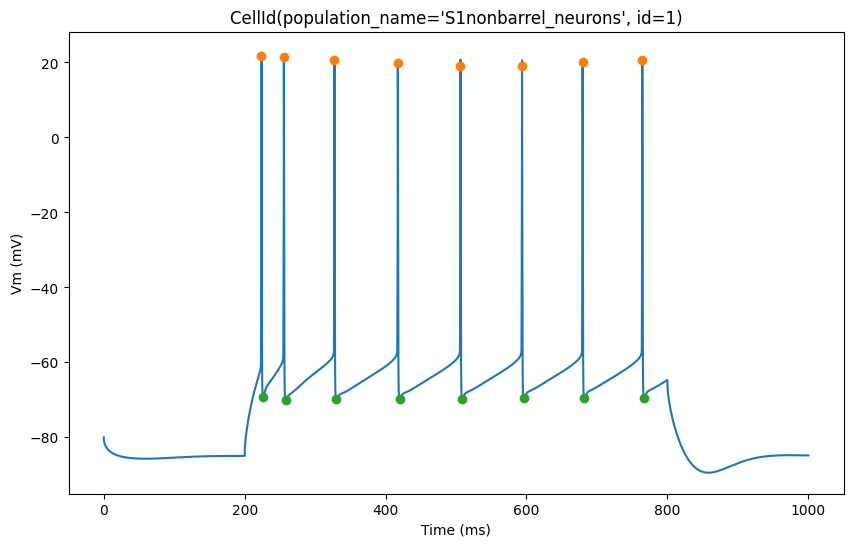

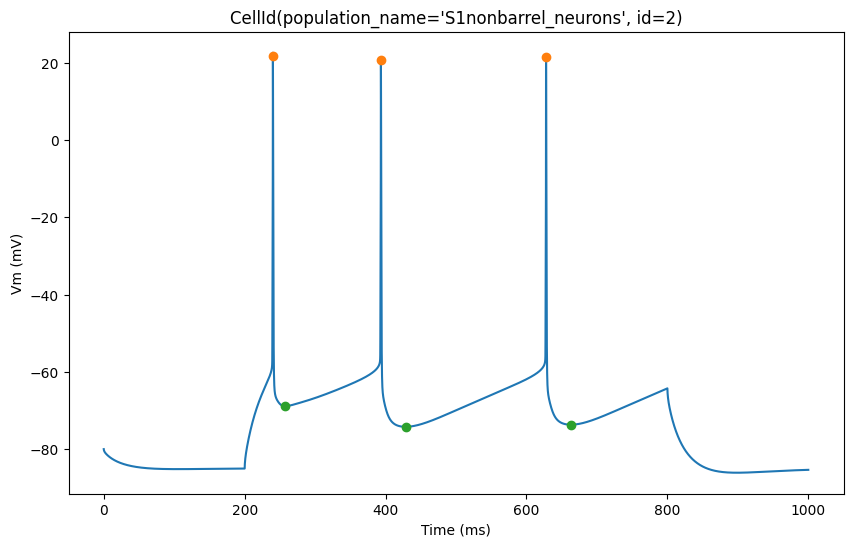

In [13]:
import pylab
for trace, trace_result, cell_id in zip(traces, traces_results, sim.cells):
    time = trace['T']
    voltage = trace['V']
    peak_times = trace_result['peak_time']
    ahp_time = trace_result['AHP_time_from_peak']
    ap_heights = trace_result['AP_height']
    AHP_depth_abss = trace_result['AHP_depth_abs']

    pylab.figure(figsize=(10, 6))
    pylab.title(cell_id)
    pylab.plot(time,voltage)
    pylab.plot(peak_times, ap_heights, 'o')
    pylab.plot(peak_times+ahp_time, AHP_depth_abss, 'o')
    pylab.xlabel('Time (ms)')
    pylab.ylabel('Vm (mV)')
    pylab.show()

Now, let's overlay the durations of the inter-spike intervals (ISIs) for a clearer visualization of the timing between spikes

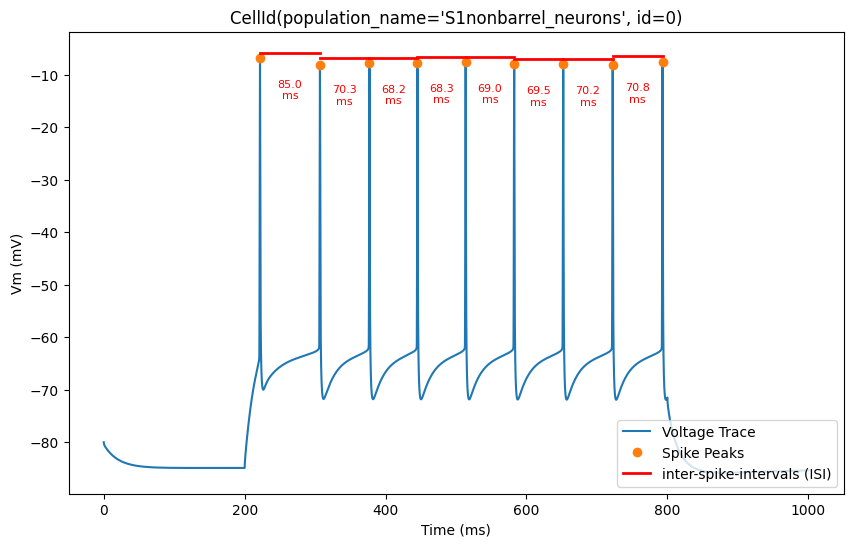

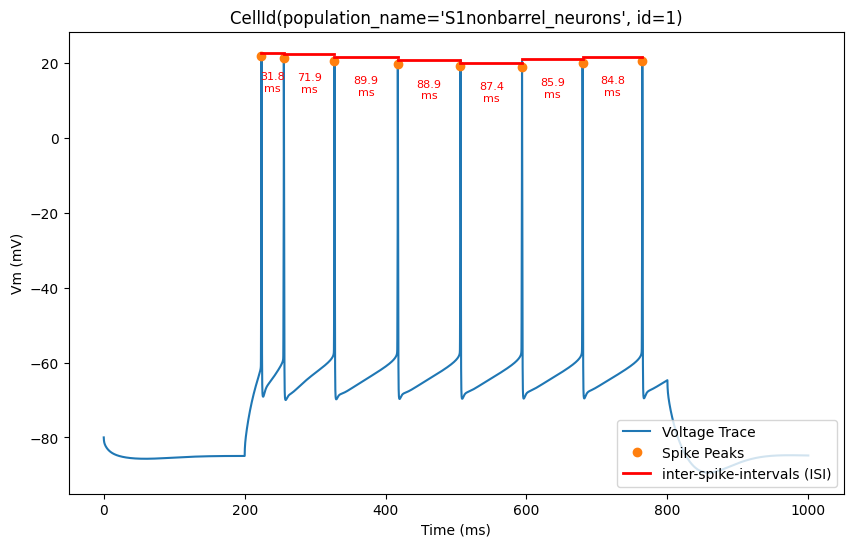

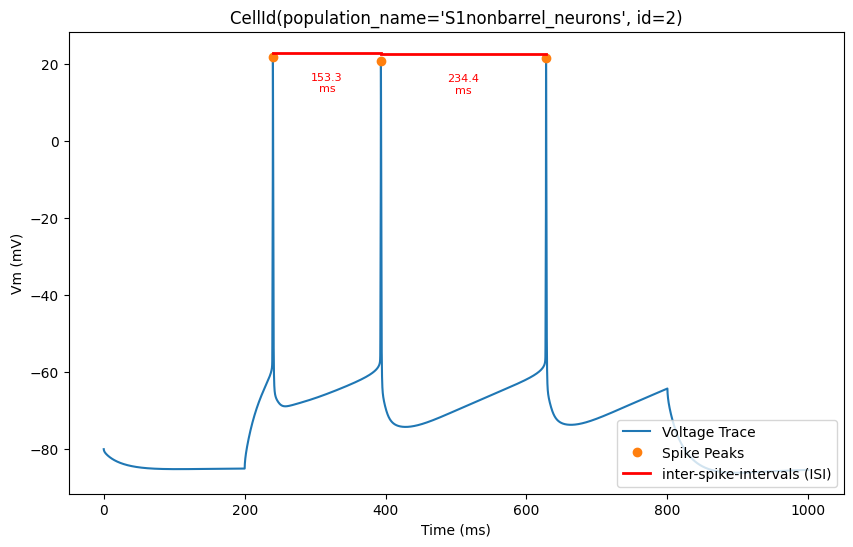

In [14]:
for trace, trace_result, cell_id in zip(traces, traces_results, sim.cells):
    time = trace['T']
    voltage = trace['V']
    peak_times = trace_result['peak_time']
    ap_heights = trace_result['AP_height']

    all_isi_values = trace_result['all_ISI_values']

    pylab.figure(figsize=(10, 6))
    pylab.title(cell_id)
    pylab.plot(time, voltage, label='Voltage Trace')
    pylab.plot(peak_times, ap_heights, 'o', label='Spike Peaks')

    for i in range(len(peak_times) - 1):
        start_spike_time = peak_times[i]
        end_spike_time = peak_times[i + 1]
        duration = round(all_isi_values[i], 2)

        y_position = max(ap_heights[i], ap_heights[i + 1]) + 1

        # Check if it's the first ISI line to be drawn and add a label, otherwise draw without a label
        if i == 0:
            pylab.plot([start_spike_time, end_spike_time], [y_position, y_position], 'r-', lw=2, label='inter-spike-intervals (ISI)')
        else:
            pylab.plot([start_spike_time, end_spike_time], [y_position, y_position], 'r-', lw=2)

        # Adjust text position to be slightly lower
        midpoint = (start_spike_time + end_spike_time) / 2
        pylab.text(midpoint, y_position - 5,
                  f'{duration}\nms',
                  verticalalignment='top',
                  horizontalalignment='center',
                  color='red', fontsize=8)

    pylab.xlabel('Time (ms)')
    pylab.ylabel('Vm (mV)')
    pylab.legend(loc='lower right')
    pylab.show()